Data processing and plot creation for latitude and longitude of SCLF distribution

In [ ]:
# load in tiles gpkg and folder with tif data

In [ ]:
# get pixel count of 1 for each *.tif and add to geopackage

In [19]:
import geopandas as gpd
from osgeo import gdal
import numpy as np
import os
import re

# Configuration
tif_folder = "../data/SCLF_model_greaterthan05/"
gpkg_path = "../data/SCLF_tiles_index.gpkg"
output_gpkg = "SCLF_tiles_greaterthan05_counts.gpkg"

def count_pixels_greaterthan05(location):
    """Count pixels with value 1 for a given location"""
    tif_path = os.path.join(tif_folder, location.replace('.tif', '_greaterthan05.tif'))
    
    if not os.path.exists(tif_path):
        print(f"File not found: {tif_path}")
        return 0
    
    try:
        ds = gdal.Open(tif_path)
        if ds is None:
            print(f"Could not open: {tif_path}")
            return 0
            
        arr = ds.GetRasterBand(1).ReadAsArray()
        pixels_count = int(np.sum(arr == 1))
        ds = None
        return pixels_count
        
    except Exception as e:
        print(f"Error processing {tif_path}: {e}")
        return 0

# Load GeoPackage
gdf = gpd.read_file(gpkg_path)

# Extract x and y coordinates from location column (e.g., "x26y40_SCLF_model.tif")
# Pattern: x followed by digits, then y followed by digits
gdf['x'] = gdf['location'].str.extract(r'x(\d+)')
gdf['y'] = gdf['location'].str.extract(r'y(\d+)')

# Convert to integer
gdf['x'] = gdf['x'].astype(int)
gdf['y'] = gdf['y'].astype(int)

# Process all rows
print(f"Processing {len(gdf)} tiles...")

# Apply the function and get pixel counts
gdf['pixels_greaterthan05'] = gdf['location'].apply(count_pixels_greaterthan05)

# Calculate area in km² (assuming 30m pixels: 900 m² = 0.0009 km² per pixel)
gdf['greaterthan05_area_km2'] = gdf['pixels_greaterthan05'] * 0.0009

# Summary
print(f"\nSummary:")
print(f"Processed {len(gdf)} files")
print(f"X coordinate range: {gdf['x'].min()} to {gdf['x'].max()}")
print(f"Y coordinate range: {gdf['y'].min()} to {gdf['y'].max()}")
print(f"Total pixels with value 1: {gdf['pixels_greaterthan05'].sum():,}")
print(f"Total area: {gdf['greaterthan05_area_km2'].sum():,.4f} km²")

# Save
gdf.to_file(output_gpkg, driver='GPKG')
print(f"\nSaved to {output_gpkg}")

Processing 271 tiles...

Summary:
Processed 271 files
X coordinate range: 26 to 68
Y coordinate range: 21 to 60
Total pixels with value 1: 13,253,783
Total area: 11,928.4047 km²

Saved to SCLF_tiles_greaterthan05_counts.gpkg


In [20]:
gdf

,location,geometry,x,y,pixels_greaterthan05,greaterthan05_area_km2
0,x26y40_SCLF_model.tif,"POLYGON ((-1920000.000 -2976000.000, -1824000....",26,40,308,0.2772
1,x26y41_SCLF_model.tif,"POLYGON ((-1920000.000 -2880000.000, -1824000....",26,41,301,0.2709
2,x26y42_SCLF_model.tif,"POLYGON ((-1920000.000 -2784000.000, -1824000....",26,42,431,0.3879
3,x26y43_SCLF_model.tif,"POLYGON ((-1920000.000 -2688000.000, -1824000....",26,43,30668,27.6012
4,x26y44_SCLF_model.tif,"POLYGON ((-1920000.000 -2592000.000, -1824000....",26,44,18,0.0162
...,...,...,...,...,...,...
266,x67y40_SCLF_model.tif,"POLYGON ((2016000.000 -2976000.000, 2112000.00...",67,40,272202,244.9818
267,x67y41_SCLF_model.tif,"POLYGON ((2016000.000 -2880000.000, 2112000.00...",67,41,474177,426.7593
268,x67y42_SCLF_model.tif,"POLYGON ((2016000.000 -2784000.000, 2112000.00...",67,42,106127,95.5143
269,x68y41_SCLF_model.tif,"POLYGON ((2112000.000 -2880000.000, 2208000.00...",68,41,498,0.4482


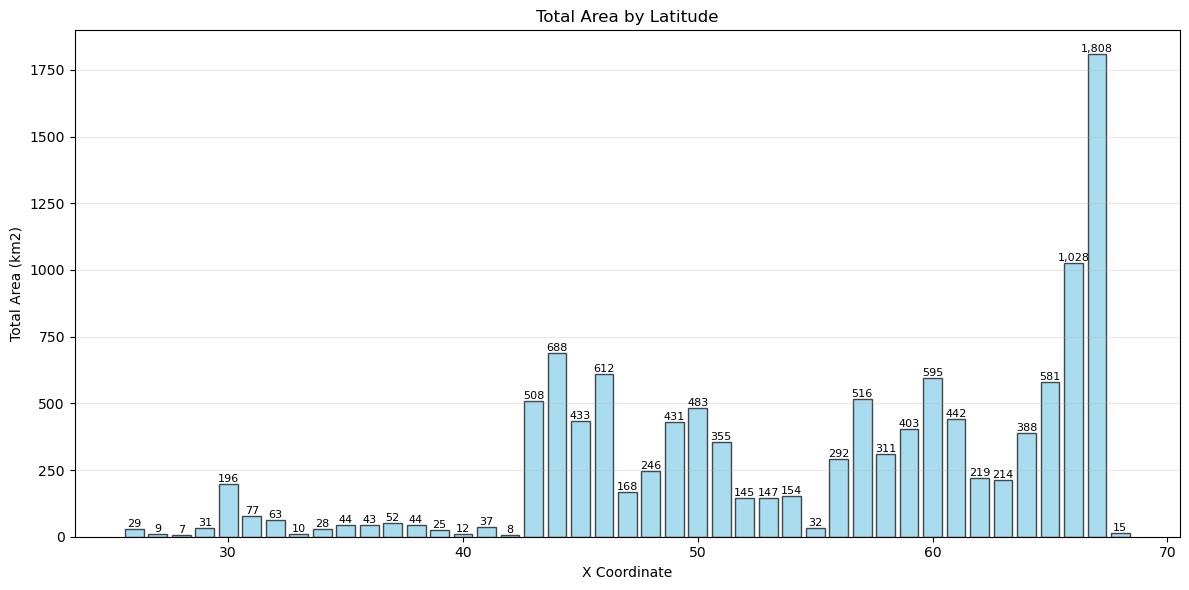

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Simple histogram of area distribution by x coordinate
plt.figure(figsize=(12, 6))

# Group by x coordinate and sum area
area_by_x = gdf.groupby('x')['greaterthan05_area_km2'].sum()

# Create histogram
plt.bar(area_by_x.index, area_by_x.values, alpha=0.7, color='skyblue', edgecolor='black')
plt.xlabel('X Coordinate')
plt.ylabel('Total Area (km2)')
plt.title('Total Area across Latitude')
plt.grid(axis='y', alpha=0.3)

# Add value labels on top of bars
for i, v in enumerate(area_by_x.values):
    plt.text(area_by_x.index[i], v, f'{v:,.0f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
# plt.savefig('area_by_x_histogram.png', dpi=150)
plt.show()

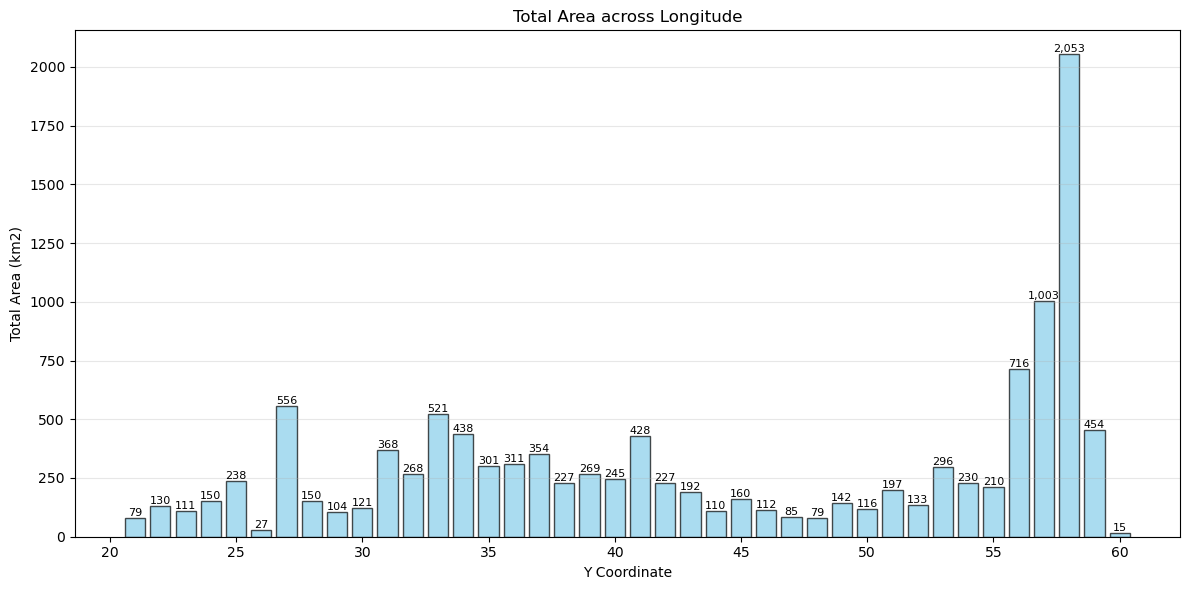

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# Simple histogram of area distribution by x coordinate
plt.figure(figsize=(12, 6))

# Group by x coordinate and sum area
area_by_y = gdf.groupby('y')['greaterthan05_area_km2'].sum()

# Create histogram
plt.bar(area_by_y.index, area_by_y.values, alpha=0.7, color='skyblue', edgecolor='black')
plt.xlabel('Y Coordinate')
plt.ylabel('Total Area (km2)')
plt.title('Total Area across Longitude')
plt.grid(axis='y', alpha=0.3)

# Add value labels on top of bars
for i, v in enumerate(area_by_y.values):
    plt.text(area_by_y.index[i], v, f'{v:,.0f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
# plt.savefig('area_by_x_histogram.png', dpi=150)
plt.show()